# Forecast Consumption

Forecasting using timeseries model the consumption of water, gas and electricity.

https://www.tensorflow.org/tutorials/structured_data/time_series#setup



In [53]:
from os import path
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# from core.data_manager import read_data_csv_df

# Variables
# add the path to the sys.path
sys.path.append(str(Path.cwd().parents[0]))


# "data_storage", "resampled_data_D_gas.csv"



In [10]:
# function to read the data
def read_data_csv_df(directory: str, filename: str) -> pd.DataFrame:
    path=Path.cwd().parents[0]
    try:
        df = pd.read_csv(path.joinpath(directory,filename))
        return df
    except FileNotFoundError:
        print(f"File {filename} not found")
        print("Please verify the file nameand path and try again")
        exit()

In [11]:
df_gas_daily = read_data_csv_df("data_storage", "resampled_data_D_gas.csv")
df_water_daily = read_data_csv_df("data_storage", "resampled_data_D_water.csv")
df_electricity_daily = read_data_csv_df("data_storage", "resampled_data_D_power.csv")

In [12]:
# df = pd.read_csv(path.joinpath("data_storage", "resampled_data_D_gas.csv"))
df_gas_daily.columns
print(df_gas_daily.columns)
df_gas_daily.head()

Index(['date', 'id_meter', 'gas_m3', 'calc_cons'], dtype='object')


,date,id_meter,gas_m3,calc_cons
0,2014-09-04,1.0,38911.506000,NaN
1,2014-09-05,1.0,38912.741875,1.235875
2,2014-09-06,1.0,38913.977750,1.235875
3,2014-09-07,1.0,38915.213625,1.235875
4,2014-09-08,1.0,38916.449500,1.235875


## Preparing the data

## Electricity

In [15]:


df_electricity_daily.info()
df_electricity_daily.describe()

power_daily_df = df_electricity_daily.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4780 entries, 0 to 4779
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       4780 non-null   object 
 1   id_meter   4780 non-null   float64
 2   power_kwh  4780 non-null   float64
 3   calc_cons  4777 non-null   float64
dtypes: float64(3), object(1)
memory usage: 149.5+ KB


In [16]:
# show duplicate dates in the data
power_daily_df[power_daily_df.duplicated(subset=["date"], keep=False)]

,date,id_meter,power_kwh,calc_cons
0,2014-09-04,4.0,51419.300000,NaN
1,2014-09-05,4.0,51422.141748,2.841748
2,2014-09-06,4.0,51424.983495,2.841748
3,2014-09-07,4.0,51427.825243,2.841748
4,2014-09-08,4.0,51430.666990,2.841748
5,2014-09-09,4.0,51433.508738,2.841748
6,2014-09-10,4.0,51436.350485,2.841748
7,2014-09-11,4.0,51439.192233,2.841748
8,2014-09-12,4.0,51442.033981,2.841748
9,2014-09-13,4.0,51444.875728,2.841748


In [17]:
# sort by date
power_daily_df.sort_values(by=["date"], inplace=True)
# show date 2021-04-01
power_daily_df[power_daily_df["date"] < "2021-04-03"]

,date,id_meter,power_kwh,calc_cons
3560,2011-06-01,7.0,0.000000,NaN
3561,2011-06-02,7.0,4.068562,4.068562
3562,2011-06-03,7.0,8.137124,4.068562
3563,2011-06-04,7.0,12.205686,4.068562
3564,2011-06-05,7.0,16.274247,4.068562
...,...,...,...,...
2399,2021-03-29,5.0,94.914286,3.328571
2400,2021-03-30,5.0,98.242857,3.328571
2401,2021-03-31,5.0,101.571429,3.328571
2402,2021-04-01,5.0,104.900000,3.328571


In [18]:
print(power_daily_df.head())
# Dealing with missing values
# # show NaN values rows
# gas_monthly_df[gas_monthly_df.isnull().any(axis=1)]

# # show duplicate rows
# gas_monthly_df[gas_monthly_df.duplicated()]

# # show rows for date 2014-09-04
# gas_monthly_df[gas_monthly_df['date'] == '2014-09-04']

# # agregate by id_meter, date
# power_daily_df = power_daily_df.groupby(["id_meter", "date"]).agg("sum").reset_index()

# # agregate by date, if id_meter is the same, sum the values, else keep both values
# power_daily_df = (
#     power_daily_df.groupby(["date"])
#     .agg(
#         {
#             "calc_cons": "sum",
#             "id_meter": lambda x: ", ".join(map(str, x)),
#         }
#     )
#     .reset_index()
# )

# # in the column id_meter, keep only one value
# power_daily_df["id_meter"] = power_daily_df["id_meter"].apply(lambda x: x.split(",")[0])

# # convert id_meter to float
# power_daily_df["id_meter"] = power_daily_df["id_meter"].astype(float)

# # in the column id_meter, keep only the value that is last in the list
# power_daily_df["id_meter"] = power_daily_df["id_meter"].apply(
#     lambda x: x.split(",")[-1]
# )
# # remove empty spaces in the column id_meter
# power_daily_df["id_meter"] = power_daily_df["id_meter"].str.strip()

# fill row 0 NaN value with 0
power_daily_df = power_daily_df.fillna(0, inplace=False)

# # drop duplicate rows keeping the last row
# power_daily_df.drop_duplicates(subset=["date"], keep="last", inplace=True)

# # show duplicate dates rows
# gas_monthly_df[gas_monthly_df.duplicated(['date'])]

# # # drop duplicate dates rows
# # gas_monthly_df.drop_duplicates(subset=['date'], inplace=False)

# # convert date column to datetime
# power_daily_df["date"] = pd.to_datetime(power_daily_df["date"])


power_daily_df.info()

# # verify that there are not missing dates in the data
# gas_monthly_df['date'] = pd.to_datetime(gas_monthly_df['date'])
# gas_monthly_df['date'].diff().dt.days

            date  id_meter  power_kwh  calc_cons
3560  2011-06-01       7.0   0.000000        NaN
3561  2011-06-02       7.0   4.068562   4.068562
3562  2011-06-03       7.0   8.137124   4.068562
3563  2011-06-04       7.0  12.205686   4.068562
3564  2011-06-05       7.0  16.274247   4.068562
<class 'pandas.core.frame.DataFrame'>
Index: 4780 entries, 3560 to 3559
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       4780 non-null   object 
 1   id_meter   4780 non-null   float64
 2   power_kwh  4780 non-null   float64
 3   calc_cons  4780 non-null   float64
dtypes: float64(3), object(1)
memory usage: 186.7+ KB


In [19]:
# drop columns not columns 1 to 3
# gas_daily_df = gas_daily_df.drop(gas_daily_df.columns[1:3], axis=1, inplace=False)

power_daily_df.head()

# unique values in id_meter column
power_daily_df["id_meter"].unique()

# # show values with id_meter == 11
# power_daily_df[power_daily_df['id_meter'] == 11]

array([7., 4., 5.])

In [20]:
# show 0 values in calc_cons column
power_daily_df[power_daily_df["calc_cons"] == 0]

,date,id_meter,power_kwh,calc_cons
3560,2011-06-01,7.0,0.0,0.0
0,2014-09-04,4.0,51419.3,0.0
2374,2021-03-04,5.0,11.7,0.0


In [33]:
# show duplicate dates in the data
power_daily_df[power_daily_df.duplicated(subset=["date"], keep=False)]



,date,id_meter,power_kwh,calc_cons


In [22]:
# remove from 2014-09-04 to 2014-10-02 if the id meter is equal to 4.0
power_daily_df = power_daily_df[
    ~((power_daily_df["date"] >= "2014-09-04") & (power_daily_df["date"] <= "2014-10-02"))
    | (power_daily_df["id_meter"] != 4.0)
]

In [23]:
# show duplicate dates in the data
power_daily_df[power_daily_df.duplicated(subset=["date"], keep=False)]

,date,id_meter,power_kwh,calc_cons
2373,2021-03-04,4.0,57234.2,2.133333
2374,2021-03-04,5.0,11.7,0.000000


In [24]:
# aggregate duplicate values in the data 2021-03-04
power_daily_df = power_daily_df.groupby(["date"]).agg("sum").reset_index()

In [25]:
# show duplicate dates in the data
power_daily_df[power_daily_df.duplicated(subset=["date"], keep=False)]

,date,id_meter,power_kwh,calc_cons


In [26]:
power_daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4750 entries, 0 to 4749
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       4750 non-null   object 
 1   id_meter   4750 non-null   float64
 2   power_kwh  4750 non-null   float64
 3   calc_cons  4750 non-null   float64
dtypes: float64(3), object(1)
memory usage: 148.6+ KB


In [27]:
# show duplicate dates rows
power_daily_df[power_daily_df.duplicated(["date"])]

,date,id_meter,power_kwh,calc_cons


In [57]:
# # convert date column to datetime
# power_daily_df["date"] = pd.to_datetime(power_daily_df["date"])
# # set date column as index
# power_daily_df.set_index("date", inplace=True)

In [28]:
# sort by date
power_daily_df = power_daily_df.sort_values(by="date")

In [29]:
power_daily_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4750 entries, 0 to 4749
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       4750 non-null   object 
 1   id_meter   4750 non-null   float64
 2   power_kwh  4750 non-null   float64
 3   calc_cons  4750 non-null   float64
dtypes: float64(3), object(1)
memory usage: 148.6+ KB


In [30]:
power_daily_df.describe()

,id_meter,power_kwh,calc_cons
count,4750.000000,4750.000000,4750.000000
mean,5.021053,27649.911428,2.729564
std,1.234540,26186.142045,0.965127
min,4.000000,0.000000,0.000000
25%,4.000000,1796.025637,2.040741
50%,5.000000,3688.517742,2.796154
75%,7.000000,53817.628226,3.531034
max,9.000000,57245.900000,4.400000


In [34]:
power_daily_df.tail(10)

,date,id_meter,power_kwh,calc_cons
4740,2024-05-23,5.0,3761.193548,3.545161
4741,2024-05-24,5.0,3764.738710,3.545161
4742,2024-05-25,5.0,3768.283871,3.545161
4743,2024-05-26,5.0,3771.829032,3.545161
4744,2024-05-27,5.0,3775.374194,3.545161
4745,2024-05-28,5.0,3778.919355,3.545161
4746,2024-05-29,5.0,3782.464516,3.545161
4747,2024-05-30,5.0,3786.009677,3.545161
4748,2024-05-31,5.0,3789.554839,3.545161
4749,2024-06-01,5.0,3793.100000,3.545161


In [38]:
# convert date column to date
power_daily_df["date"] = pd.to_datetime(power_daily_df["date"])


In [45]:
power_daily_df.isna().sum()
power_daily_df.dtypes
# power_daily_df.describe()



date         datetime64[ns]
id_meter            float64
power_kwh           float64
calc_cons           float64
dtype: object

In [43]:
power_daily_df["date"].tail(50)

4700   2024-04-13
4701   2024-04-14
4702   2024-04-15
4703   2024-04-16
4704   2024-04-17
4705   2024-04-18
4706   2024-04-19
4707   2024-04-20
4708   2024-04-21
4709   2024-04-22
4710   2024-04-23
4711   2024-04-24
4712   2024-04-25
4713   2024-04-26
4714   2024-04-27
4715   2024-04-28
4716   2024-04-29
4717   2024-04-30
4718   2024-05-01
4719   2024-05-02
4720   2024-05-03
4721   2024-05-04
4722   2024-05-05
4723   2024-05-06
4724   2024-05-07
4725   2024-05-08
4726   2024-05-09
4727   2024-05-10
4728   2024-05-11
4729   2024-05-12
4730   2024-05-13
4731   2024-05-14
4732   2024-05-15
4733   2024-05-16
4734   2024-05-17
4735   2024-05-18
4736   2024-05-19
4737   2024-05-20
4738   2024-05-21
4739   2024-05-22
4740   2024-05-23
4741   2024-05-24
4742   2024-05-25
4743   2024-05-26
4744   2024-05-27
4745   2024-05-28
4746   2024-05-29
4747   2024-05-30
4748   2024-05-31
4749   2024-06-01
Name: date, dtype: datetime64[ns]

In [46]:
# slice date column to get year, month, day
power_daily_df["year"] = power_daily_df["date"].dt.year
power_daily_df["month"] = power_daily_df["date"].dt.month
power_daily_df["day"] = power_daily_df["date"].dt.day

power_daily_df.head()

,date,id_meter,power_kwh,calc_cons,year,month,day
0,2011-06-01,7.0,0.000000,0.000000,2011,6,1
1,2011-06-02,7.0,4.068562,4.068562,2011,6,2
2,2011-06-03,7.0,8.137124,4.068562,2011,6,3
3,2011-06-04,7.0,12.205686,4.068562,2011,6,4
4,2011-06-05,7.0,16.274247,4.068562,2011,6,5


## Prepare the model

## Hypothesis

Assuming that what is expected is a prediction for:
- a day
- a month
- a season (summer, winter,... )
- a year

For an specific utility (gas, water, electricity)

With data taken at the beggining every year, then esporadicly monthly, then ussually mintlhy with some extra measures , made manually.

Data sources from a DB with measures from different location, type of building, insulation difference, weather variation, 

Parameters to consider:
- Weather
- inhabitants in the house
- normal time / vacation time (would mean, that can be more or less people in the house, as measures are made at the end before and after returning from vacation it could helo)

???
- Could be necessary to use only the data that has more ocnsistency and more information, less assumptions?
- Made sense have the info from 2 places if the granurality is not the same?


### H0:
if consumption parameter is used as X
1. if it is used with the daily interpolation made from theintiial data 
- if it used in a daily base the interporaltion made would made the model less accurrate, 
- if it used in a has to be in a monthly base, as the daily information is a calculation doing previously and the line is so qdjusted that would not have sesn

### H1:

In [56]:
# drop date column
# power_daily_df.drop("date", axis=1, inplace=True)

power_daily_df.head()

power_daily_prep_df = power_daily_df.copy()

In [ ]:
# drop columns power_kwh
# power_daily_prep_df.drop("power_kwh", axis=1, inplace=True)



,id_meter,calc_cons,year,month,day,dayofweek,dayofyear,quarter,day_sin,day_cos,month_sin,month_cos,year_sin,year_cos,dayofweek_sin,dayofweek_cos,dayofyear_sin,dayofyear_cos,quarter_sin,quarter_cos
0,7.0,0.000000,2011,6,1,2,152,2,0.201299,0.979530,1.224647e-16,-1.0,-0.031084,0.999517,0.974928,-0.222521,0.507415,-0.861702,1.224647e-16,-1.0
1,7.0,4.068562,2011,6,2,3,153,2,0.394356,0.918958,1.224647e-16,-1.0,-0.031084,0.999517,0.433884,-0.900969,0.492548,-0.870285,1.224647e-16,-1.0
2,7.0,4.068562,2011,6,3,4,154,2,0.571268,0.820763,1.224647e-16,-1.0,-0.031084,0.999517,-0.433884,-0.900969,0.477536,-0.878612,1.224647e-16,-1.0
3,7.0,4.068562,2011,6,4,5,155,2,0.724793,0.688967,1.224647e-16,-1.0,-0.031084,0.999517,-0.974928,-0.222521,0.462383,-0.886680,1.224647e-16,-1.0
4,7.0,4.068562,2011,6,5,6,156,2,0.848644,0.528964,1.224647e-16,-1.0,-0.031084,0.999517,-0.781831,0.623490,0.447094,-0.894487,1.224647e-16,-1.0


In [62]:
# Split the data into training and test sets
X = power_daily_prep_df.drop("calc_cons", axis=1)
y = power_daily_prep_df["calc_cons"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

# # save the data
# power_daily_prep_df.to_csv(path.joinpath("data_storage", "resampled_data_D_power_prep.csv"), index=False)
# X_train.to_csv(path.joinpath("data_storage", "resampled_data_D_power_prep_X_train.csv"), index=False)
# X_test.to_csv(path.joinpath("data_storage", "resampled_data_D_power_prep_X_test.csv"), index=False)
# y_train.to_csv(path.joinpath("data_storage", "resampled_data_D_power_prep_y_train.csv"), index=False)
# y_test.to_csv(path.joinpath("data_storage", "resampled_data_D_power_prep_y_test.csv"), index=False)




((3800, 19), (950, 19), (3800,), (950,))

In [63]:
# standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [64]:
# print the first 5 rows of the scaled data
X_train_scaled[:5]


array([[-8.15927692e-01,  4.18000776e-01,  1.00764172e+00,
        -7.70924524e-01, -5.01286581e-01,  9.36008782e-01,
         1.33414226e+00,  1.36659851e+00, -3.43753439e-01,
        -1.23540261e+00,  6.97721623e-01,  4.17963060e-01,
         7.69451218e-01,  1.36556352e+00, -3.15659906e-01,
        -1.41112112e+00,  1.73645588e-01, -2.98992077e-03,
         1.40386296e+00],
       [-8.15927692e-01, -1.14930930e-01,  1.42126680e-01,
        -1.56152489e+00,  1.50280496e+00,  2.23638737e-03,
         4.41582296e-01,  5.60134356e-01,  1.32066752e+00,
        -7.14011272e-01, -1.22044223e+00, -1.14999425e-01,
         3.64801735e-01, -1.10705485e+00,  8.86579073e-01,
        -4.55090914e-03, -1.41762818e+00, -1.42320229e+00,
        -4.44729553e-03],
       [-8.15927692e-01, -6.47862635e-01,  1.42126680e-01,
        -8.83867434e-01, -5.01286581e-01,  5.88286537e-02,
         4.41582296e-01,  1.40966745e+00, -5.91374629e-02,
        -7.14011272e-01, -1.22044223e+00, -6.47920699e-01,
    

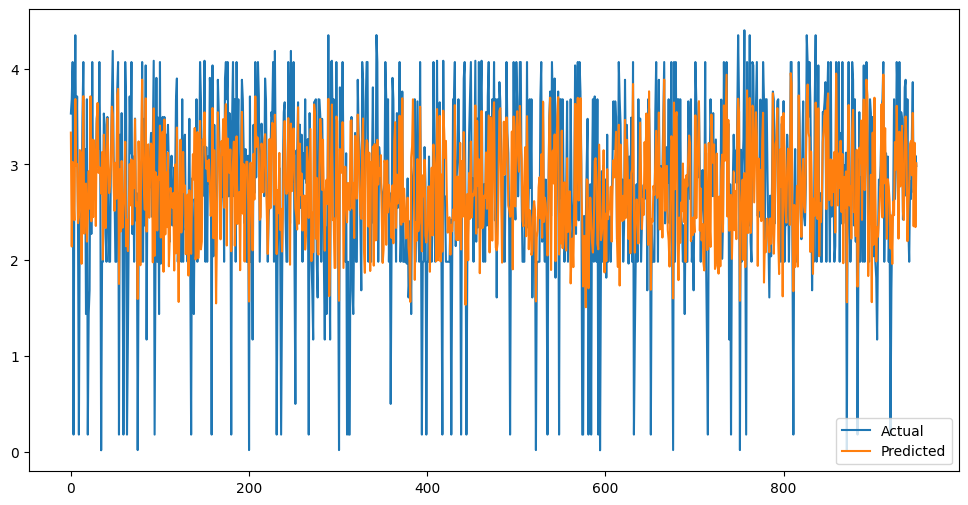

In [65]:
# creating, fitting and predicting the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# print the first 5 predictions
y_pred[:5]

# evaluate the model
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

# plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()



In [66]:
rmse

0.7917518328910899

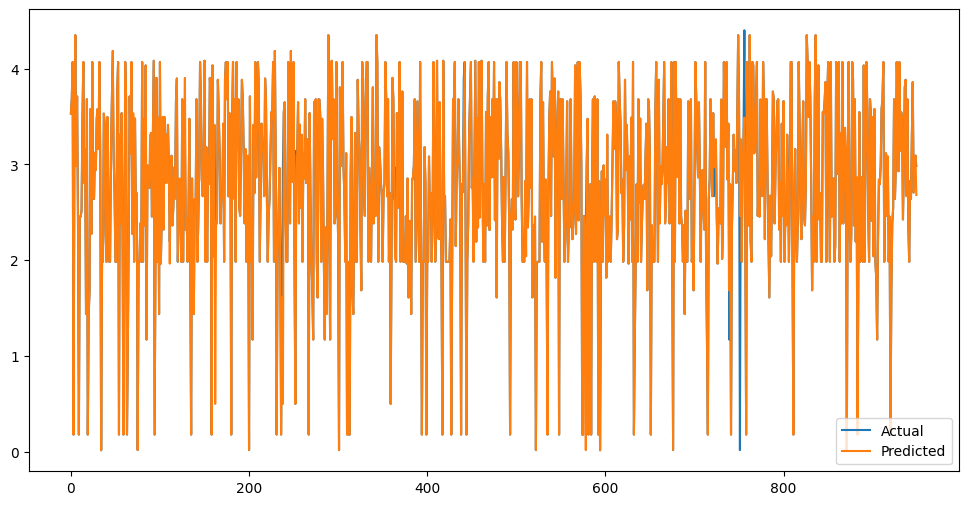

0.16668742413356263

In [67]:
# creating, fitting and predicting the model decision tree
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

# plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

rmse

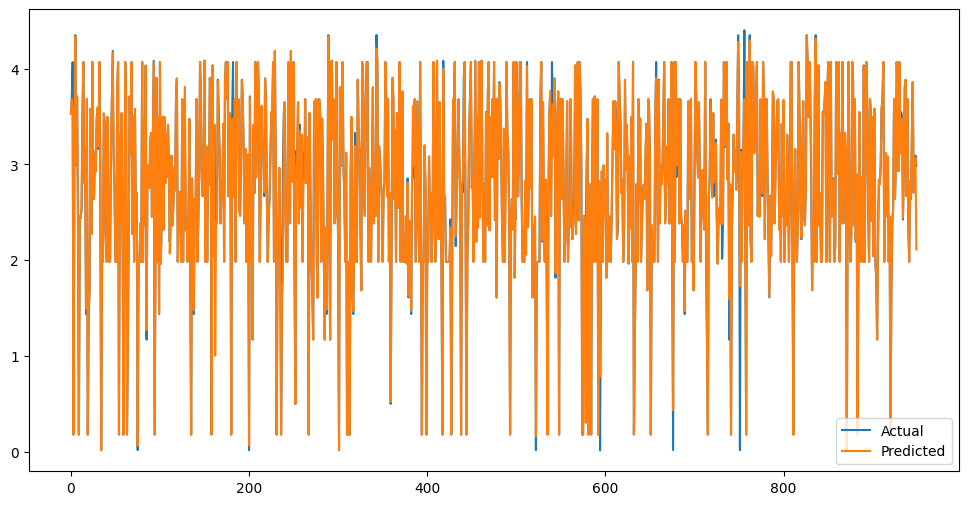

0.14436417796472165

In [68]:
# creating, fitting and predicting the model random forest
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

# plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

rmse


2025-01-05 14:55:25.900051: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-05 14:55:26.064851: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-05 14:55:28.832051: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Epoch 1/100


2025-01-05 14:55:34.521307: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/dev/projects/CATY_Management/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 4.2748
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8621
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8858
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.8102
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.8144
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.7985
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7888
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7306
Epoch 9/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.7224
Epoch 10/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.7839
Epoch 11/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.7164
Epoch 12/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7202
Epoch 13/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7252
Epoch 14/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7359
Epoch 15/100
119/119 ━━━━━━━━━━━━━━━━━━━━

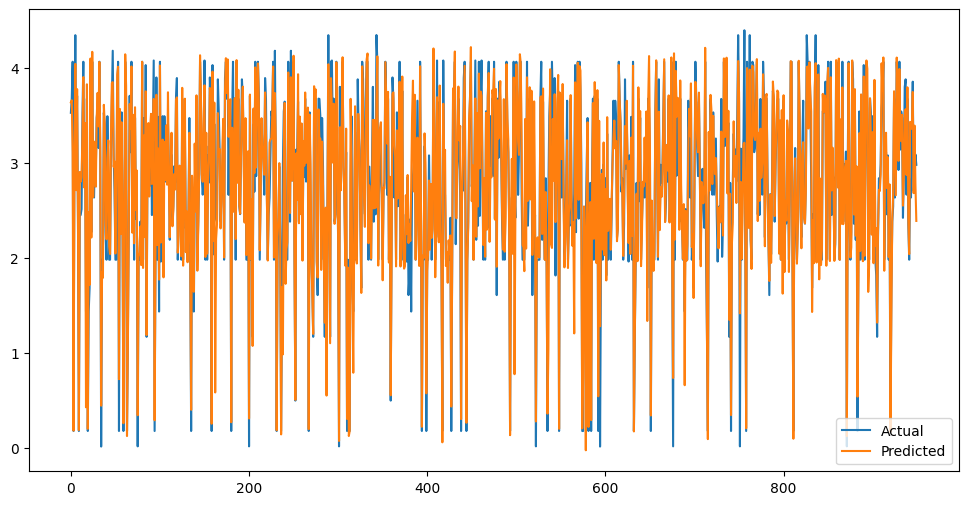

0.3193535984504407

In [69]:
# creating, fitting and predicting the model 4/gru model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(GRU(64, input_shape=(X_train_scaled.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer=Adam(0.001), loss="mse")

X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=1)
y_pred = model.predict(X_test_scaled)

# evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

# plot the predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

rmse

In [70]:
# predict consumption for the next 30 days
X_pred = power_daily_prep_df.tail(30).drop("calc_cons", axis=1)
X_pred_scaled = scaler.transform(X_pred)

X_pred_scaled = X_pred_scaled.reshape(X_pred_scaled.shape[0], X_pred_scaled.shape[1], 1)
y_pred = model.predict(X_pred_scaled)

y_pred



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[3.5205765],
       [3.4392042],
       [3.4759953],
       [3.3702726],
       [3.3225532],
       [3.289729 ],
       [3.2559505],
       [3.341188 ],
       [3.3161898],
       [3.3842273],
       [3.3391638],
       [3.3025088],
       [3.2751904],
       [3.3101454],
       [3.396656 ],
       [3.4033036],
       [3.38355  ],
       [3.3317401],
       [3.2569249],
       [3.2061594],
       [3.2925568],
       [3.3670259],
       [3.368434 ],
       [3.2715378],
       [3.2228017],
       [3.1077266],
       [3.0367243],
       [3.073308 ],
       [3.2061055],
       [3.2318723]], dtype=float32)

In [71]:
# predict consumption for the next year
X_pred = power_daily_prep_df.tail(365).drop("calc_cons", axis=1)
X_pred_scaled = scaler.transform(X_pred)

X_pred_scaled = X_pred_scaled.reshape(X_pred_scaled.shape[0], X_pred_scaled.shape[1], 1)
y_pred = model.predict(X_pred_scaled)

y_pred

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[2.8787942 ],
       [2.9121342 ],
       [2.9997969 ],
       [2.8758202 ],
       [2.7546785 ],
       [2.6585717 ],
       [2.6603577 ],
       [2.5918055 ],
       [2.7020597 ],
       [2.8047156 ],
       [2.780302  ],
       [2.6982174 ],
       [2.696784  ],
       [2.854341  ],
       [2.804213  ],
       [2.8486018 ],
       [2.7776184 ],
       [2.7099845 ],
       [2.6100006 ],
       [2.7093625 ],
       [2.9730906 ],
       [2.9579794 ],
       [2.7581296 ],
       [2.7169456 ],
       [2.578364  ],
       [2.4519675 ],
       [2.5444353 ],
       [2.6858006 ],
       [1.6181902 ],
       [1.3083594 ],
       [1.5669316 ],
       [1.1894155 ],
       [0.79321855],
       [0.90714234],
       [0.79358363],
       [0.82086873],
       [0.6456135 ],
       [0.55278677],
       [0.64400375],
       [0.4293964 ],
       [0.46748698],
       [0.70771456],
       [0.8883035 ],
       [0.76055783],
       [0.66201675],
       [0.7746604 ],
       [0.6039031 ],
       [0.762

In [ ]:
# add to the data the predicted values and dates for the next year
power_daily_pred_df = power_daily_prep_df.copy()
power_daily_pred_df["date"] = pd.to_datetime(power_daily_pred_df["date"])
last_date = power_daily_pred_df["date"].max()
date_range = pd.date_range(start=last_date, periods=365, freq="D")
y_pred = y_pred.flatten()
df_pred = pd.DataFrame({"date": date_range, "calc_cons": y_pred})
power_daily_pred_df = pd.concat([power_daily_pred_df, df_pred], axis=0)

power_daily_pred_df.tail(10)



## Featured Engineering

In [47]:
# convert time
# convert date to seconds to made it more readable
power_daily_df["date"] = pd.to_datetime(power_daily_df["date"])

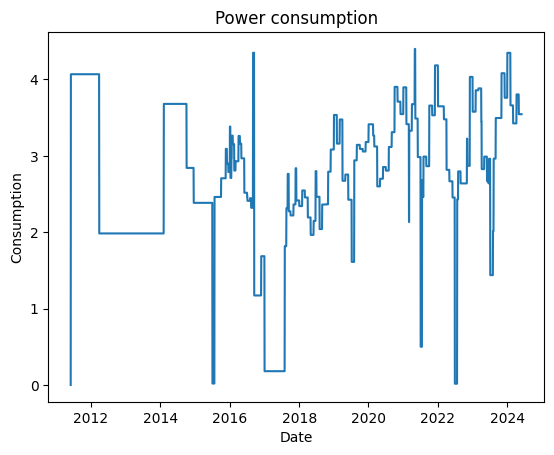

In [50]:
# assuming daily, weekly, monthly, yearly perioditicity
# daily
power_daily_df["day"] = power_daily_df["date"].dt.day
power_daily_df["month"] = power_daily_df["date"].dt.month
power_daily_df["year"] = power_daily_df["date"].dt.year
power_daily_df["dayofweek"] = power_daily_df["date"].dt.dayofweek
power_daily_df["dayofyear"] = power_daily_df["date"].dt.dayofyear
# power_daily_df["week"] = power_daily_df["date"].dt.week
power_daily_df["quarter"] = power_daily_df["date"].dt.quarter

# # weekly
# power_daily_df["week"] = power_daily_df["date"].dt.week

# monthly
power_daily_df["month"] = power_daily_df["date"].dt.month

# yearly
power_daily_df["year"] = power_daily_df["date"].dt.year

# show the first rows
power_daily_df.head()

# plot the data
plt.plot(np.array(power_daily_df["date"]), np.array(power_daily_df["calc_cons"]))
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.title("Power consumption")
plt.show()

# plt.plot(np.array(power_daily_df["day"]), np.array(power_daily_df["calc_cons"]))
# plt.xlabel("Day")
# plt.ylabel("Consumption")
# plt.title("Power consumption")
# plt.show()

Text(0.5, 1.0, 'Time of day signal')

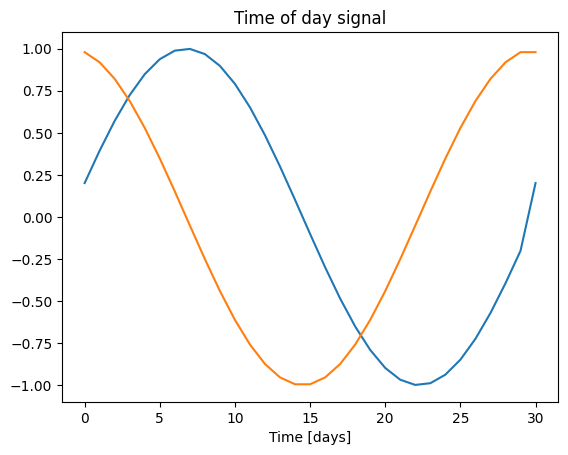

In [51]:
# using cosine and sine to encode the cyclical nature of time
# day
power_daily_df["day_sin"] = np.sin(power_daily_df["day"] * (2 * np.pi / 31))
power_daily_df["day_cos"] = np.cos(power_daily_df["day"] * (2 * np.pi / 31))
# month
power_daily_df["month_sin"] = np.sin(power_daily_df["month"] * (2 * np.pi / 12))
power_daily_df["month_cos"] = np.cos(power_daily_df["month"] * (2 * np.pi / 12))
# year
power_daily_df["year_sin"] = np.sin(power_daily_df["year"] * (2 * np.pi / 2021))
power_daily_df["year_cos"] = np.cos(power_daily_df["year"] * (2 * np.pi / 2021))
# dayofweek
power_daily_df["dayofweek_sin"] = np.sin(power_daily_df["dayofweek"] * (2 * np.pi / 7))
power_daily_df["dayofweek_cos"] = np.cos(power_daily_df["dayofweek"] * (2 * np.pi / 7))
# dayofyear
power_daily_df["dayofyear_sin"] = np.sin(
    power_daily_df["dayofyear"] * (2 * np.pi / 366)
)
power_daily_df["dayofyear_cos"] = np.cos(
    power_daily_df["dayofyear"] * (2 * np.pi / 366)
)
# quarter
power_daily_df["quarter_sin"] = np.sin(power_daily_df["quarter"] * (2 * np.pi / 4))
power_daily_df["quarter_cos"] = np.cos(power_daily_df["quarter"] * (2 * np.pi / 4))

# # show the first rows
power_daily_df.head()

plt.plot(np.array(power_daily_df["day_sin"])[:31])
plt.plot(np.array(power_daily_df["day_cos"])[:31])
plt.xlabel("Time [days]")
plt.title("Time of day signal")

Fast Fourier Transform???

This gives the model access to the most important frequency features. In this case you knew ahead of time which frequencies were important.

If you don't have that information, you can determine which frequencies are important by extracting features with Fast Fourier Transform. To check the assumptions, here is the tf.signal.rfft of the temperature over time. Note the obvious peaks at frequencies near 1/year and 1/day:


```python
fft = tf.signal.rfft(df['T (degC)'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['T (degC)'])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=['1/Year', '1/day'])
_ = plt.xlabel('Frequency (log scale)')
```

In [23]:
# Split the data
# split the data into train, validation, and test set
# train set is 70% of the data
# validation set is 15% of the data
# test set is 15% of the data
"""
You'll use a (70%, 20%, 10%) split for the training, validation, and test sets. Note the data is not being randomly shuffled before splitting. This is for two reasons:
It ensures that chopping the data into windows of consecutive samples is still possible.
It ensures that the validation/test results are more realistic, being evaluated on the data collected after the model was trained.
"""
n = len(power_daily_df)
train_df = power_daily_df[0 : int(n * 0.7)]
val_df = power_daily_df[int(n * 0.7) : int(n * 0.85)]
test_df = power_daily_df[int(n * 0.85) :]
# check the length of the data
print(len(train_df), len(val_df), len(test_df))

num_features = power_daily_df.shape[1]

print(f"Number of features = {num_features}")

3325 712 713
Number of features = 22


A Large Comparison of Normalization Methods on Time Series
https://www.sciencedirect.com/science/article/abs/pii/S2214579623000400
https://link.springer.com/chapter/10.1007/978-3-031-11432-8_8
Normalization is a mandatory preprocessing step in time series problems to guarantee similarity comparisons invariant to unexpected distortions in amplitude and offset. Such distortions are usual for most time series data. 

In [24]:
# Normalize the data
# normalize the data using the mean and standard deviation of the training data
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

# # show the first rows
train_df.head()

/tmp/ipykernel_6728/1963666855.py:6: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  train_df = (train_df - train_mean) / train_std
/tmp/ipykernel_6728/1963666855.py:7: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  val_df = (val_df - train_mean) / train_std
/tmp/ipykernel_6728/1963666855.py:8: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  test_df = (test_df - train_mean) / train_std


,date,id_meter,power_kwh,calc_cons,day,month,year,dayofweek,dayofyear,quarter,...,month_sin,month_cos,year_sin,year_cos,dayofweek_sin,dayofweek_cos,dayofyear_sin,dayofyear_cos,quarter_sin,quarter_cos
0,-1.73127,1.313351,-1.38344,-2.613306,-1.669404,-0.151047,-1.679387,-0.499925,-0.295327,-0.453672,...,0.007956,-1.386756,-1.679238,-2.067633,1.378549,-0.314645,0.716826,-1.195648,0.009397,-1.399038
1,-1.730228,1.313351,-1.383278,1.619402,-1.555884,-0.151047,-1.679387,0.0,-0.285791,-0.453672,...,0.007956,-1.386756,-1.679238,-2.067633,0.613512,-1.273971,0.695724,-1.207742,0.009397,-1.399038
2,-1.729186,1.313351,-1.383116,1.619402,-1.442365,-0.151047,-1.679387,0.499925,-0.276254,-0.453672,...,0.007956,-1.386756,-1.679238,-2.067633,-0.613512,-1.273971,0.674416,-1.219474,0.009397,-1.399038
3,-1.728145,1.313351,-1.382954,1.619402,-1.328845,-0.151047,-1.679387,0.99985,-0.266717,-0.453672,...,0.007956,-1.386756,-1.679238,-2.067633,-1.378549,-0.314645,0.652908,-1.230841,0.009397,-1.399038
4,-1.727103,1.313351,-1.382792,1.619402,-1.215326,-0.151047,-1.679387,1.499774,-0.25718,-0.453672,...,0.007956,-1.386756,-1.679238,-2.067633,-1.10551,0.881615,0.631206,-1.24184,0.009397,-1.399038


/tmp/ipykernel_6728/464633000.py:1: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  df_std = (power_daily_df - train_mean) / train_std
/tmp/ipykernel_6728/464633000.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(power_daily_df.keys(), rotation=90)


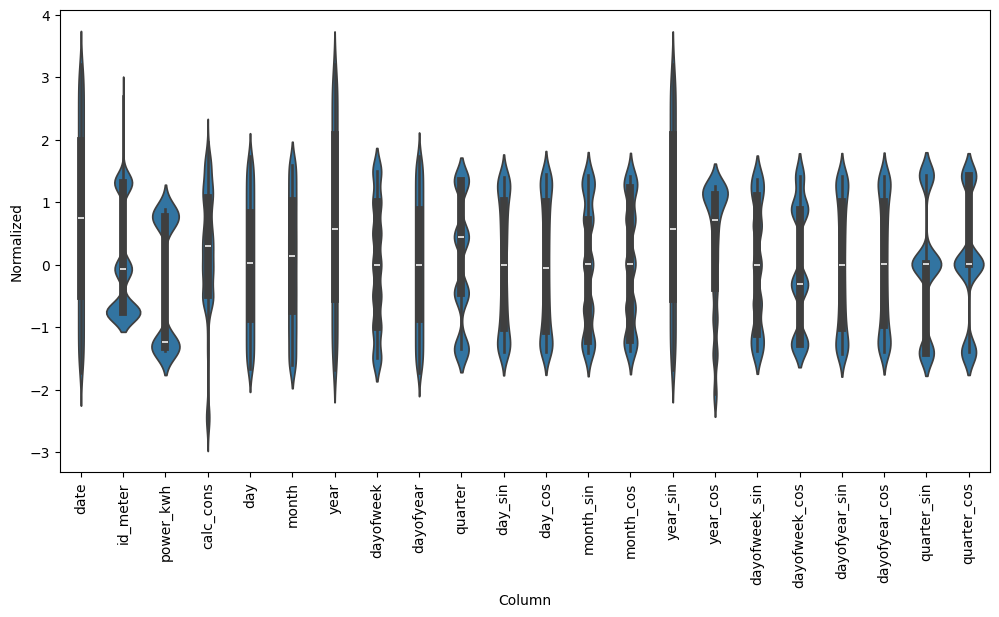

In [25]:
df_std = (power_daily_df - train_mean) / train_std
df_std = df_std.melt(var_name="Column", value_name="Normalized")
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x="Column", y="Normalized", data=df_std)
_ = ax.set_xticklabels(power_daily_df.keys(), rotation=90)

## Data windowing

The models in this tutorial will make a set of predictions based on a window of consecutive samples from the data.

The main features of the input windows are:

- The width (number of time steps) of the input and label windows.
- The time offset between them.
- Which features are used as inputs, labels, or both.

This tutorial builds a variety of models (including Linear, DNN, CNN and RNN models), and uses them for both:

- Single-output, and multi-output predictions.
- Single-time-step and multi-time-step predictions.

This section focuses on implementing the data windowing so that it can be reused for all of those models.

The rest of this section defines a WindowGenerator class. This class can:

1. Handle the indexes and offsets as shown in the diagrams above.
2. Split windows of features into (features, labels) pairs.
3. Plot the content of the resulting windows.
4. Efficiently generate batches of these windows from the training, evaluation, and test data, using tf.data.Datasets.


In [26]:
# Indexes and offsets
"""
Start by creating the WindowGenerator class. The __init__ method includes all the necessary logic for the input and label indices.
It also takes the training, evaluation, and test DataFrames as input. These will be converted to tf.data.Datasets of windows later.
"""


class WindowGenerator:
    def __init__(
        self,
        input_width,
        label_width,
        shift,
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        label_columns=None,
    ):
        # Store the raw data.
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Work out the label column indices.
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {
                name: i for i, name in enumerate(label_columns)
            }
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}

        # Work out the window parameters.
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return "\n".join(
            [
                f"Total window size: {self.total_window_size}",
                f"Input indices: {self.input_indices}",
                f"Label indices: {self.label_indices}",
                f"Label column name(s): {self.label_columns}",
            ]
        )

In [27]:
w1 = WindowGenerator(
    input_width=24, label_width=1, shift=24, label_columns=["calc_cons"]
)
w1

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['calc_cons']

In [28]:
w2 = WindowGenerator(input_width=6, label_width=1, shift=1, label_columns=["calc_cons"])
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['calc_cons']

In [29]:
# Split into windows
"""
The WindowGenerator object can split the DataFrame into these sequences. The __init__ and split_window methods are for this purpose.
The split_window method will convert a single DataFrame into a window of inputs and a window of labels.
The example WindowGenerator w2 will be used to demonstrate the split.
"""


def split_window(self, features):
    inputs = features[:, self.input_slice, :]
    labels = features[:, self.labels_slice, :]
    if self.label_columns is not None:
        labels = tf.stack(
            [labels[:, :, self.column_indices[name]] for name in self.label_columns],
            axis=-1,
        )

    # Slicing doesn't preserve static shape information, so set the shapes manually.
    inputs.set_shape([None, self.input_width, None])
    labels.set_shape([None, self.label_width, None])

    return inputs, labels

In [30]:
WindowGenerator.split_window = split_window

In [31]:
# Stack three slices, the length of the total window:
example_window = tf.stack(
    [
        np.array(train_df[: w2.total_window_size]),
        np.array(train_df[100 : 100 + w2.total_window_size]),
        np.array(train_df[200 : 200 + w2.total_window_size]),
    ]
)

example_inputs, example_labels = w2.split_window(example_window)

print("All shapes are: (batch, time, features)")
print(f"Window shape: {example_window.shape}")
print(f"Inputs shape: {example_inputs.shape}")
print(f"labels shape: {example_labels.shape}")

All shapes are: (batch, time, features)
Window shape: (3, 7, 22)
Inputs shape: (3, 6, 22)
labels shape: (3, 1, 1)


2025-01-05 10:50:08.601963: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [32]:
# Plot
w2.example = example_inputs, example_labels

In [33]:
def plot(self, model=None, plot_col="calc_cons", max_subplots=3):
    inputs, labels = self.example
    plt.figure(figsize=(12, 8))
    plot_col_index = self.column_indices[plot_col]
    max_n = min(max_subplots, len(inputs))
    for n in range(max_n):
        plt.subplot(3, 1, n + 1)
        plt.ylabel(f"{plot_col} [normed]")
        plt.plot(
            self.input_indices,
            inputs[n, :, plot_col_index],
            label="Inputs",
            marker=".",
            zorder=-10,
        )

        if self.label_columns:
            label_col_index = self.label_columns_indices.get(plot_col, None)
        else:
            label_col_index = plot_col_index

        if label_col_index is None:
            continue

        plt.scatter(
            self.label_indices,
            labels[n, :, label_col_index],
            edgecolors="k",
            label="Labels",
            c="#2ca02c",
            s=64,
        )
        if model is not None:
            predictions = model(inputs)
            plt.scatter(
                self.label_indices,
                predictions[n, :, label_col_index],
                marker="X",
                edgecolors="k",
                label="Predictions",
                c="#ff7f0e",
                s=64,
            )

        if n == 0:
            plt.legend()

    plt.xlabel("Time [h]")


WindowGenerator.plot = plot

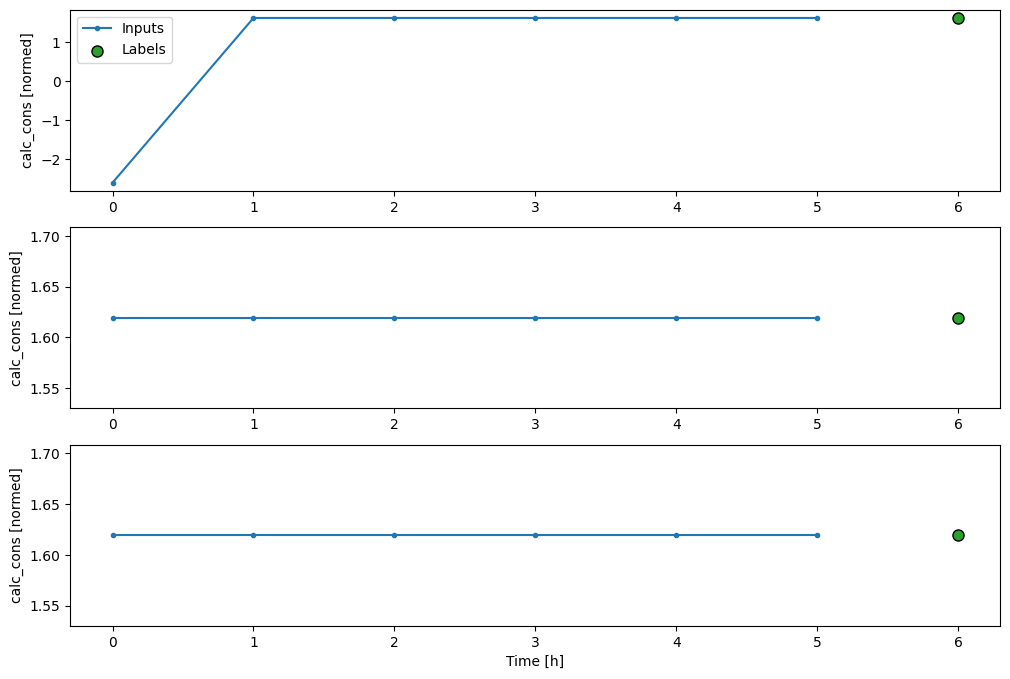

In [34]:
w2.plot()

In [35]:
# create tf.data.Dataset
def make_dataset(self, data):
    data = np.array(data, dtype=np.float32)
    ds = tf.keras.preprocessing.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=self.total_window_size,
        sequence_stride=1,
        shuffle=True,
        batch_size=32,
    )

    ds = ds.map(self.split_window)

    return ds


WindowGenerator.make_dataset = make_dataset

In [37]:
@property
def train(self):
    return self.make_dataset(self.train_df)


@property
def val(self):
    return self.make_dataset(self.val_df)


@property
def test(self):
    return self.make_dataset(self.test_df)


@property
def example(self):
    """Get and cache an example batch of `inputs, labels` for plotting."""
    result = getattr(self, "_example", None)
    if result is None:
        # No example batch was found, so get one from the `.train` dataset
        result = next(iter(self.train))
        # And cache it for next time
        self._example = result
    return result


WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [38]:
# Each element is an (inputs, label) pair
w2.train.element_spec

(TensorSpec(shape=(None, 6, 22), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [39]:
# iterate over the dataset
for example_inputs, example_labels in w2.train.take(1):
    print(f"Inputs shape (batch, time, features): {example_inputs.shape}")
    print(f"Labels shape (batch, time, features): {example_labels.shape}")

Inputs shape (batch, time, features): (32, 6, 22)
Labels shape (batch, time, features): (32, 1, 1)


2025-01-05 10:50:58.014449: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [40]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1, label_columns=["calc_cons"]
)
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['calc_cons']

In [41]:
for example_inputs, example_labels in single_step_window.train.take(1):
    print(f"Inputs shape (batch, time, features): {example_inputs.shape}")
    print(f"Labels shape (batch, time, features): {example_labels.shape}")

Inputs shape (batch, time, features): (32, 1, 22)
Labels shape (batch, time, features): (32, 1, 1)


2025-01-05 10:51:08.155565: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Baseline

In [44]:
class Baseline(tf.keras.Model):
    def __init__(self, label_index=None):
        super().__init__()
        self.label_index = label_index

    def call(self, inputs):
        if self.label_index is None:
            return inputs
        result = inputs[:, :, self.label_index]
        return result[:, :, tf.newaxis]

In [45]:
# instantiate and evaluate the baseline model
baseline = Baseline(label_index=column_indices["calc_cons"])

baseline.compile(
    loss=tf.keras.losses.MeanSquaredError(), metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

val_performance = {}
performance = {}
val_performance["Baseline"] = baseline.evaluate(single_step_window.val, return_dict=True)
performance["Baseline"] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

NameError: name 'column_indices' is not defined

In [88]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1, label_columns=["calc_cons"]
)

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['calc_cons']

In [89]:
print("Input shape:", wide_window.example[0].shape)
print("Output shape:", baseline(wide_window.example[0]).shape)

Input shape: (32, 24, 22)


NameError: name 'baseline' is not defined

In [48]:
wide_window.plot(baseline)

NameError: name 'baseline' is not defined

In [49]:
linear = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(units=1),
    ]
)

In [50]:
print("Input shape:", single_step_window.example[0].shape)
print("Output shape:", linear(single_step_window.example[0]).shape)

Input shape: (32, 1, 22)
Output shape: (32, 1, 1)


In [51]:
from tkinter.tix import MAX


MAX_EPOCHS = 20

def compile_and_fit(model, window, patience=2):
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, mode="min"
    )

    model.compile(
        loss=tf.losses.MeanSquaredError(),
        optimizer=tf.optimizers.Adam(),
        metrics=[tf.metrics.MeanAbsoluteError()],
    )

    history = model.fit(
        window.train,
        epochs=MAX_EPOCHS,
        validation_data=window.val,
        callbacks=[early_stopping],
    )
    return history

/tmp/ipykernel_6728/2868924038.py:1: DeprecationWarning: The Tix Tk extension is unmaintained, and the tkinter.tix wrapper module is deprecated in favor of tkinter.ttk
  from tkinter.tix import MAX
